Chana Neuhaus

6/18/2026

Bellevue University, DSC 350

# Week 2 Exercise: Linear Regression and Scatterplots

### Preprocessing

In [102]:
#importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

In [103]:
#importing csv dataset as df, displaying info and sample rows
df = pd.read_csv("car_data.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   weight   205 non-null    int64
 1   hwy_mpg  205 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


,weight,hwy_mpg
0,2548,27
1,2548,27
2,2823,26
3,2337,30
4,2824,22


### Scatterplot

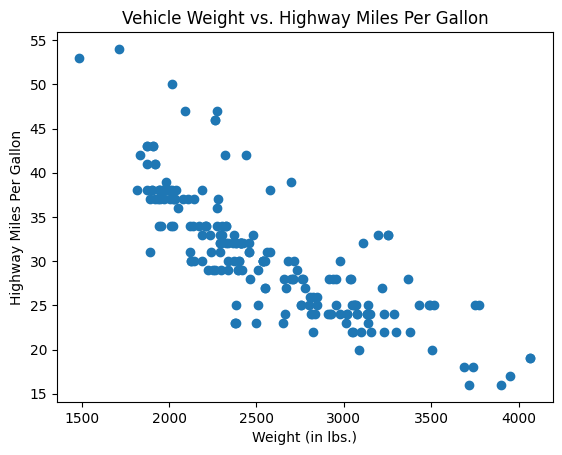

In [37]:
#creating scatterplot, with weight as x axis, and highway mpg as y axis
plt.scatter(df["weight"], df["hwy_mpg"])
plt.title("Vehicle Weight vs. Highway Miles Per Gallon")
plt.xlabel("Weight (in lbs.)")
plt.ylabel("Highway Miles Per Gallon")
plt.show()

Though the data is not especially tight, from looking at the scatterplot, there seems to be a definite downward trend, where the greater the weight, the less highway miles per gallon. This  would indicate a negative slope.

If the slope would be -.05, then with every additional pound, the highway miles per gallon would be .05 times less.

### Trendline

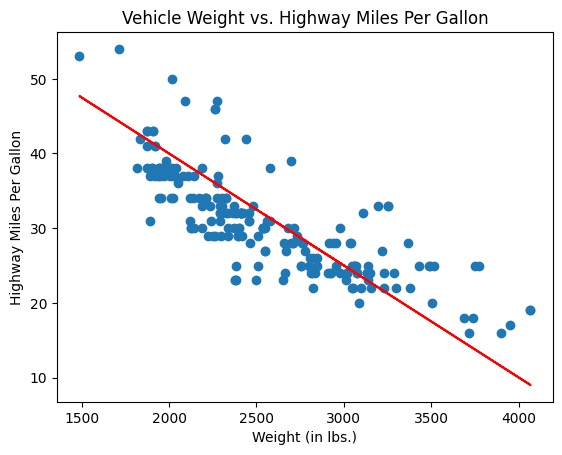

Slope = -0.015
y-intercept = 70


In [104]:
#adding "eyeballed" line to scatterplot
m = -.015
b = 70
plt.scatter(df["weight"], df["hwy_mpg"])
plt.title("Vehicle Weight vs. Highway Miles Per Gallon")
base_preds = m * df["weight"] + b
plt.plot(df["weight"], y_preds, color="red" )
plt.xlabel("Weight (in lbs.)")
plt.ylabel("Highway Miles Per Gallon")
plt.show()
print(f"Slope = {m}")
print(f"y-intercept = {b}")

I experimented until I found a line which I seemed to fit the data. The intercept was 70, and the slope was .015

### Linear Regression in Sklearn

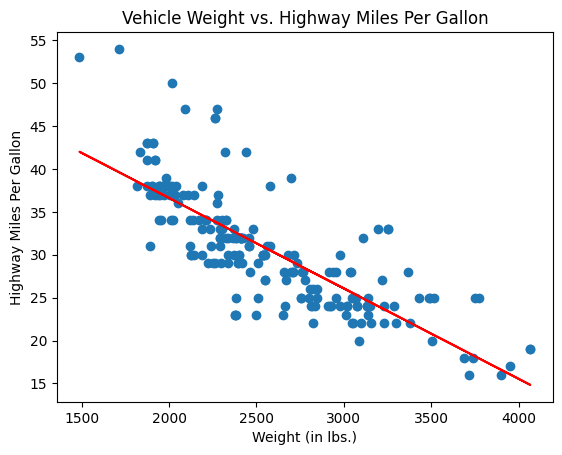

Slope = [-0.01054716]
y-intercept = 57.70517422574474


In [106]:
#initiating sklearn linear regression model
lr = LinearRegression()

#fitting model to data
model = lr.fit(df[["weight"]], df["hwy_mpg"])

#predicting dependent variable for data
y_pred = model.predict(df[["weight"]])

#creating scatter plot with best line of fit
plt.scatter(df["weight"], df["hwy_mpg"])
plt.plot(df["weight"], y_pred,  color = "red")
plt.title("Vehicle Weight vs. Highway Miles Per Gallon")
plt.xlabel("Weight (in lbs.)")
plt.ylabel("Highway Miles Per Gallon")
plt.show()

#finding slope and y-intercept of best line of fit
print(f"Slope = {model.coef_}")
print(f"y-intercept = {model.intercept_}")

###RMSE

In [110]:
#evaluating and printing model scores for "eyeballed" line (base model), and sklearn best line of fit
print("MODEL EVALUATION")
print("-"*60)
print("Base Model: ")
print(f"\t Root Mean Squared Error: {root_mean_squared_error(df["hwy_mpg"], base_preds)}")
print("-"*60)
print("Actual Best Fit:")
print(f"\t Root Mean Squared Error: {root_mean_squared_error(df["hwy_mpg"], y_pred)}")
print("-"*60)

MODEL EVALUATION
------------------------------------------------------------
Base Model: 
	 Root Mean Squared Error: 4.833960313973748
------------------------------------------------------------
Actual Best Fit:
	 Root Mean Squared Error: 4.144895442072009
------------------------------------------------------------


The root mean squared error of both model is pretty similar, but the the actual best fit line (from sklearn) is slightly lower, indicating better model performance. Since this line was found with actual mathematical calculations, I would expect it to perform better. Additionally, looking at the line on the scatterplots, the best fit line seems to do a better job at predicting more points.

###Sample Prediction

In [109]:
#using best line of fit to predict highway miles per gallon for new sample
sample = pd.DataFrame({"weight": [3200]})
prediction = model.predict(sample)
print(prediction)

[23.95427129]
